## 1. Import Libraries & Load Dataset

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")

## 2. Check Ireelevant Columns: 
In these block we will check the the percentage of missing data per column and number of unique values per column

In [27]:
print("--- Missing Data Percentage ---")
print(df.isnull().mean() * 100)

print("\n--- Unique Values Per Column ---")
print(df.nunique())

--- Missing Data Percentage ---
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

--- Unique Values Per Column ---
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


## 3. Data Cleaning:
In this block we will fill miing values and drop irrelevant columns

In [28]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.drop(columns=["Cabin", "PassengerId", "Name", "Ticket"], inplace=True, errors='ignore')

print("\n--- Missing Data Count After Cleaning ---")
print(df.isnull().sum())


--- Missing Data Count After Cleaning ---
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## 4. Creating New Variables: age groups, family size

In [29]:
# 1. Create Age Groups (Child, Teen, YoungAdult, Adult, Senior)
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

# 2. Create a Family Size feature
df["FamilySize"] = df["SibSp"] + df["Parch"]

print(df[["Age", "AgeGroup", "SibSp", "Parch", "FamilySize"]].head())

    Age    AgeGroup  SibSp  Parch  FamilySize
0  22.0  YoungAdult      1      0           1
1  38.0       Adult      1      0           1
2  26.0  YoungAdult      0      0           0
3  35.0       Adult      1      0           1
4  35.0       Adult      0      0           0


## 4. Data Analysis 

In [30]:
print("1. Survival Rate by Age Group (%):")

print(df.groupby("AgeGroup")["Survived"].mean() * 100)
print("-" * 30)

print("\n2. Survival Rate by Embarkation Port (%):")
print(df.groupby("Embarked")["Survived"].mean() * 100)
print("-" * 30)

print("\n3. Survival Rate by Family Size (%):")
print(df.groupby("FamilySize")["Survived"].mean() * 100)

1. Survival Rate by Age Group (%):
AgeGroup
Child         57.971014
Teen          42.857143
YoungAdult    33.109620
Adult         42.323651
Senior        34.375000
Name: Survived, dtype: float64
------------------------------

2. Survival Rate by Embarkation Port (%):
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64
------------------------------

3. Survival Rate by Family Size (%):
FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


### **Insights**

Based on the numerical data extracted above, here are the key findings regarding survival rates on the Titanic:

1. **Survival by Age Group:** 
   The data clearly reflects the "women and children first" maritime protocol. The **Child** age group had the highest survival rate of all age categories, while the **Senior** group had the lowest chance of survival. 

2. **Survival by Embarkation Port:** 
   Passengers who boarded at **Cherbourg (C)** survived at a notably higher rate than those who boarded at Queenstown (Q) or Southampton (S). This is often correlated with a higher concentration of 1st-class passengers boarding at Cherbourg.

3. **Survival by Family Size:** 
   Survival was highest for passengers traveling in **small families** (1 to 3 additional family members). Solo travelers (Family Size = 0) had lower survival rates, likely because they had no one to assist them. Conversely, survival chances dropped dramatically for very large families (4+ members), as staying together during the chaotic evacuation proved incredibly difficult.

## 5. Data Visualizations
 
### 1. Age Distribution (Histogram)
First, we will look at the age distribution of the passengers using a histogram. By coloring the data based on survival, we can see exactly which age brackets had the highest survival and casualty counts.

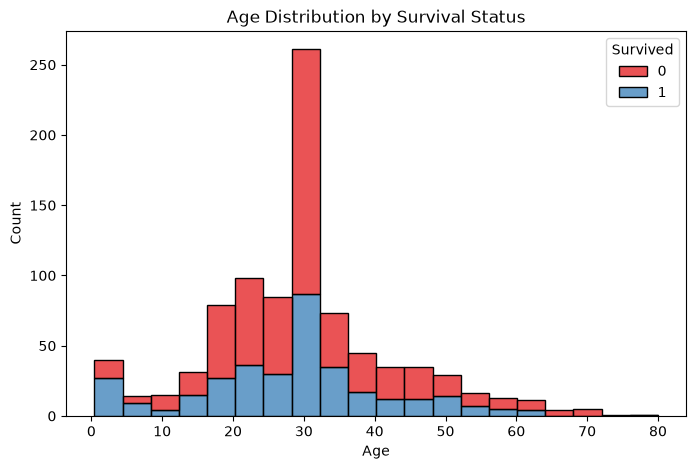

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", bins=20, palette="Set1", multiple="stack")
plt.title("Age Distribution by Survival Status")
plt.show()

**Key Insights:**
* The massive spike around age 30 is a direct result of our data cleaning step, where we filled missing values with the mean age (~29.7 years).
* The toddler age group (0-5) is the only section where the number of survivors visibly outweighs the casualties.

### 2. Survival Rate by Age Group
Next, we analyze the survival rate by Age Group. By breaking this down further by gender, we can clearly see the historical "Women and children first" protocol in the data.

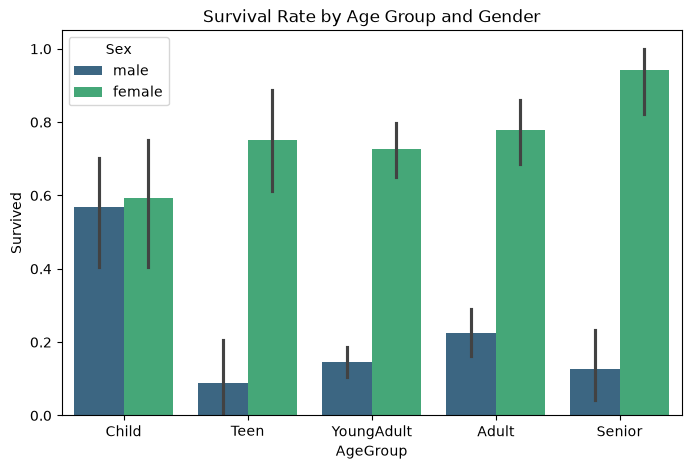

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(x="AgeGroup", y="Survived", hue="Sex", data=df, palette="viridis")
plt.title("Survival Rate by Age Group and Gender")
plt.show()

**Key Insights:**
* **Women and Children First:** The "Child" category has the highest overall survival rate. 
* Across every single age group, females survived at a drastically higher rate than males. The "Senior" male group had the absolute lowest chance of survival.

### 3. Survival Rate by Embarkation Port
This chart explores whether the port a passenger boarded at (C = Cherbourg, Q = Queenstown, S = Southampton) had any impact on their likelihood of survival.

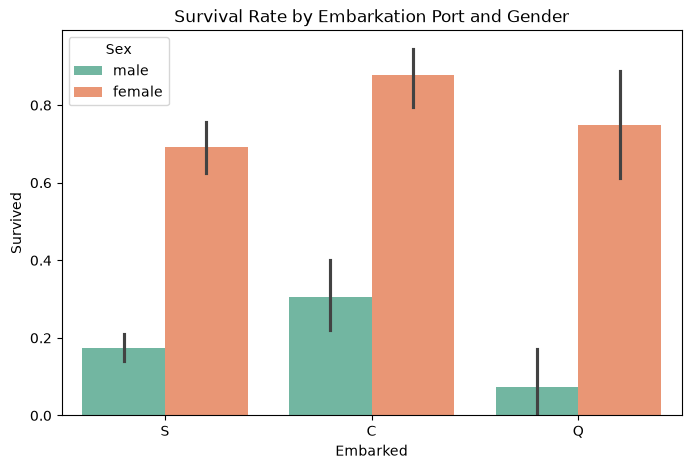

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Embarked", y="Survived", hue="Sex", data=df, palette="Set2")
plt.title("Survival Rate by Embarkation Port and Gender")
plt.show()

**Key Insights:**
* Passengers who boarded at Cherbourg (C) had the highest survival rates for both men and women. 
* Queenstown (Q) and Southampton (S) saw much lower survival rates, particularly for male passengers.

### 4. Survival by Family Size
Using our newly engineered `FamilySize` feature, we can visualize survival by family size using a bar plot[cite: 1]. This helps us understand if traveling solo, in a small family, or in a large family affected survival chances.

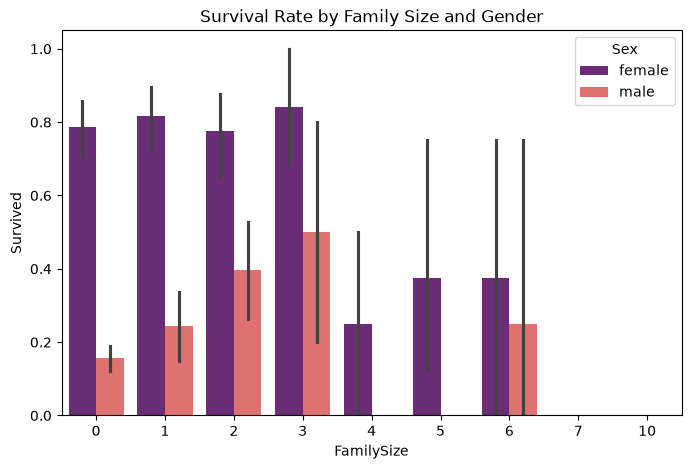

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(x="FamilySize", y="Survived", hue="Sex", data=df, palette="magma")
plt.title("Survival Rate by Family Size and Gender")
plt.show()

**Key Insights:**
* **The Sweet Spot:** Passengers traveling with 1 to 3 family members had the highest survival rates. 
* Solo travelers (Family Size = 0) struggled to survive, likely because they had no assistance. Conversely, very large families (4+ members) also faced tragic outcomes, likely due to the difficulty of keeping a large group together during the chaotic evacuation.

### 5. Correlation Heatmap
Finally, we generate a heatmap of correlations to see the mathematical relationships between all our numerical variables[cite: 1]. Positive numbers show variables that increase together, while negative numbers show inverse relationships.

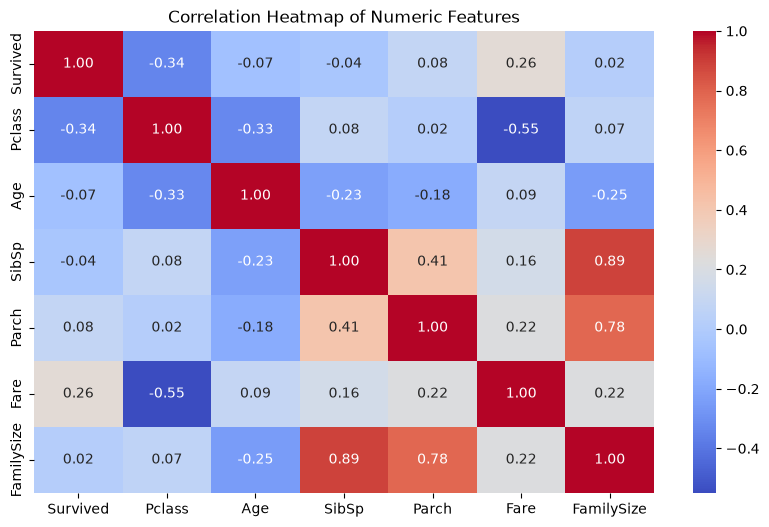

In [35]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Key Insights:**
* **Pclass and Fare:** There is a strong negative correlation between `Pclass` and `Fare`, which makes sense because 1st class (1) tickets cost more money than 3rd class (3) tickets.
* **Survival Factors:** `Survived` has a negative correlation with `Pclass`, proving that lower-class passengers (3rd class) were less likely to survive. `Survived` has a positive correlation with `Fare`, reinforcing that those who paid more had better survival odds.